In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

path = "/content/drive/MyDrive/6893/raw/20251112_0011"
print(os.listdir(path))

['473837611', '3404595', '20713882', '946974', '11253297', '_logs', '31009079', '3766866', '25910292', '286187082', '1684559452', '1825475365', '1889545341', '401742377', '3546663866075740', '624243924', '63231', '2128487337', '249118', '1369801844', '12890453', '386917389', '3546382956759627', '8482768', '27899754', '471303350', '66607740', '3546644771506784', '88461692', '37974444', '523995133', '431073645', '1459104794', '3546719514003582', '217107039', '6014992', '677063300', '109606796', '1656463436', '3546630773016865', '1340190821', '1401050701', '477676711', '718918', '65564239', '3546911659264635', '435203110', '519872016', '23947287', '1283676771', '24919812', '355804646', '504573481', '10399934', '289169707', '1242710972', '3546760219724479', '386112702', '479659041', '522976477', '520819684', '597100476', '146865230', '1562955722', '1643236766', '367877', '663528522', '3546831122336532', '347128576', '50381841', '21149898', '3546952650197324', '482867012', '3493296569583802

In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/6893/raw/20251112_0011/final_cluster_k4.csv")
df.head()

,uid,up_name,followers,n_videos,avg_play,med_play,std_play,avg_comment_scraped,med_comment_scraped,avg_danmaku,...,comment_topic_diversity,danmaku_topic_diversity,content_cohesion,comment_repetition,danmaku_repetition,comment_semantic_cohesion,danmaku_semantic_cohesion,pca_x,pca_y,cluster
0,75,丸子,1608050,20,122840.40,86304.0,1.172240e+05,100.55,101.0,170.95,...,0.120990,1.267595,0.690042,0.374941,0.333995,0.565132,0.600705,0.142137,-1.005583,1
1,63231,泛式,6527652,20,2729657.30,2551415.0,1.209302e+06,101.00,101.0,2311.00,...,0.137851,1.245517,0.666619,0.384698,0.393172,0.572876,0.656605,3.625763,-0.351249,2
2,168598,逍遥散人,7466450,20,1702112.40,1017824.0,1.963026e+06,100.90,101.0,2902.60,...,0.634106,1.403253,0.696689,0.378273,0.348799,0.589962,0.605042,2.619507,0.417290,2
3,194128,赖美云,495760,20,106008.20,23603.0,2.841340e+05,95.25,100.0,97.85,...,0.664268,1.305716,0.578819,0.477241,0.800991,0.619873,0.653390,-0.246587,-0.920671,1
4,249118,shourei小N,2203491,20,351374.25,250486.5,2.890280e+05,100.55,101.0,277.50,...,0.662397,1.255244,0.650160,0.421417,0.451783,0.584763,0.587273,0.196262,-0.746700,1


Loaded: (121, 28)
PCA explained variance ratio: [0.42222735 0.20893281]

Silhouette Score (k=2): 0.3698


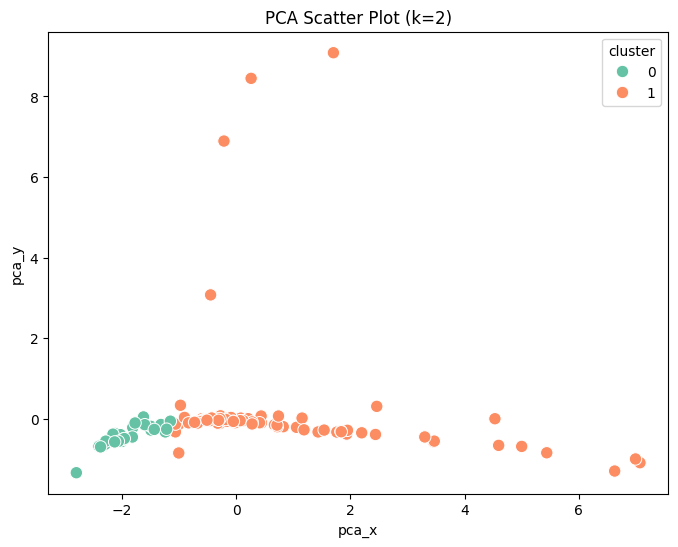

Saved: /content/drive/MyDrive/6893/raw/20251112_0011/9_features_2.csv


In [10]:
# ======================================
# 🔰 PCA + KMeans 聚类（可视化用）
# ======================================

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

RAW_DIR = Path("/content/drive/MyDrive/6893/raw/20251112_0011")

# ========= 1. Load Final Feature Table ==========
df = pd.read_csv(RAW_DIR / "final_up_profile_v2.csv", dtype={"uid": str})
print("Loaded:", df.shape)

# ========= 2. Select feature columns ==========
feature_cols = [
    "avg_length",
    "std_length",
    "upload_freq",
    "danmaku_missing_rate",
    "avg_play",
    "avg_danmaku",
    "med_play",
    "avg_comment_scraped",
    "med_danmaku"
]

df_feat = df[feature_cols].fillna(0)

# ========= 3. 标准化 ==========
scaler = StandardScaler()
X = scaler.fit_transform(df_feat)

# ========= 4. PCA ==========
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df["pca_x"] = X_pca[:, 0]
df["pca_y"] = X_pca[:, 1]

print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# ========= 5. KMeans 聚类 ==========
k = 2  # 你可以改
km = KMeans(n_clusters=k, random_state=42)
df["cluster"] = km.fit_predict(X)

sil = silhouette_score(X, df["cluster"])
print(f"\nSilhouette Score (k={k}): {sil:.4f}")

# ========= 6. Scatter Plot ==========
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="pca_x",
    y="pca_y",
    hue="cluster",
    palette="Set2",
    s=80
)
plt.title(f"PCA Scatter Plot (k={k})")
plt.show()

# ========= 7. Save ==========
out_path = RAW_DIR / f"9_features_{k}.csv"
df.to_csv(out_path, index=False, encoding="utf-8-sig")
print("Saved:", out_path)

In [11]:
# ============================================
# 🔰 打印每个 cluster 的 UP 列表（清晰分组）
# ============================================

import pandas as pd
from pathlib import Path

RAW_DIR = Path("/content/drive/MyDrive/6893/raw/20251112_0011")

k = 2  # 调这个即可

df = pd.read_csv(RAW_DIR / f"9_features_{k}.csv", dtype={"uid": str})

print(f"Loaded final_cluster_k{k}.csv:", df.shape)

# 显示这些列（可自行增减）
cols_to_show = [
    "uid", "up_name", "followers",
    "avg_play", "avg_comment_scraped",
    "avg_danmaku", "danmaku_missing_rate",
]

# 按 cluster 分组打印
for c in sorted(df["cluster"].unique()):
    print("\n" + "="*70)
    print(f"🔵 Cluster {c}")
    print("="*70)

    sub = df[df["cluster"] == c][cols_to_show]

    # 排序：按粉丝从高到低
    sub = sub.sort_values("followers", ascending=False)

    print(sub.to_string(index=False))
    print(f"\n👉 共 {len(sub)} 个 UP\n")

Loaded final_cluster_k2.csv: (121, 31)

🔵 Cluster 0
             uid       up_name  followers  avg_play  avg_comment_scraped  avg_danmaku  danmaku_missing_rate
       400813602 Ayase-YOASOBI    1601566 176226.00                51.15       108.95                  0.50
       383433896      教日语的阿飞老师    1275269   5068.20                17.45         8.60                  0.40
       679237565        张宇考研数学    1261276  22848.80                51.25        36.90                  0.25
      1369801844      普本生的求职指南     386374  46665.95                46.35         6.20                  0.30
       109606796          鹅姐职场     377674   3553.95                 4.75         6.15                  0.00
       386917389  AI编程布道者-金角大王     197607   6581.75                 7.25         1.20                  0.65
       549737999      张真源的松果仓库     158424   1530.60                 4.75         2.20                  0.40
       217107039   AI产品经理PMGao      84575  16322.85                21.80         4.1

In [7]:
import pandas as pd

# 你的原始 4 分类文件
INPUT = "/content/drive/MyDrive/6893/raw/20251112_0011/less_features_4.csv"

# 输出文件
OUTPUT = "/content/drive/MyDrive/6893/raw/20251112_0011/less_features_binary.csv"

# 读取
df = pd.read_csv(INPUT)

# 假设你的 cluster 列叫 "cluster"
# 如果名称不是 cluster，请告诉我，我帮你调整
if "cluster" not in df.columns:
    raise ValueError("CSV 里没有 cluster 列，请检查列名")

# 创建新的二分类标签列 label_binary
def map_cluster_to_label(c):
    if c in [0, 1]:   # 低价值群体
        return 0
    elif c in [2, 3]: # 高价值群体
        return 1
    else:
        return None   # 如果遇到奇怪值

df["label_binary"] = df["cluster"].apply(map_cluster_to_label)

# 保存为新文件
df.to_csv(OUTPUT, index=False)

print("转换完成！已生成文件：", OUTPUT)

# 打印每类数量
print("\n=== Cluster → Label 统计 ===")
print(df.groupby("label_binary")["uid"].count())

转换完成！已生成文件： /content/drive/MyDrive/6893/raw/20251112_0011/less_features_binary.csv

=== Cluster → Label 统计 ===
label_binary
0    30
1    91
Name: uid, dtype: int64


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# =============================
#  Load CSV
# =============================
csv_path = "/content/drive/MyDrive/6893/raw/20251112_0011/binary_features.csv"
df = pd.read_csv(csv_path)

print("Loaded:", df.shape)
print(df["label_binary"].value_counts())

# =============================
#  Feature Columns (10 dims)
# =============================
FEATURE_COLS = [
    "avg_length",
    "std_length",
    "upload_freq",
    "comment_repetition",
    "danmaku_missing_rate",
    "avg_play",
    "avg_danmaku",
    "med_play",
    "avg_comment_scraped",
    "med_danmaku"
]

X = df[FEATURE_COLS]
y = df["label_binary"]

# =============================
#  Train-test split
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# =============================
#  Model pipeline
# =============================
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ))
])

# =============================
#  Train
# =============================
model.fit(X_train, y_train)

# =============================
#  Evaluate
# =============================
y_pred = model.predict(X_test)

print("\n=== Classification Report ===\n")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===\n")
print(confusion_matrix(y_test, y_pred))

# =============================
#  Save Model
# =============================
MODEL_PATH = "/content/drive/MyDrive/6893/raw/20251112_0011/up_classifier_10dim.pkl"
joblib.dump(model, MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Loaded: (121, 32)
label_binary
1    80
0    41
Name: count, dtype: int64

=== Classification Report ===

              precision    recall  f1-score   support

           0       0.89      0.73      0.80        11
           1       0.86      0.95      0.90        20

    accuracy                           0.87        31
   macro avg       0.88      0.84      0.85        31
weighted avg       0.87      0.87      0.87        31


=== Confusion Matrix ===

[[ 8  3]
 [ 1 19]]
Model saved to: /content/drive/MyDrive/6893/raw/20251112_0011/up_classifier_10dim.pkl
